In [20]:
import sys
sys.path.append('..')
import torch
from encoder import FMEncoder, compute_spectrogram_cqt
from fm_ddsp import fm_renderer, make_mod_matrix
from nnAudio.features import CQT2010v2
import soundfile as sf
import json
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import numpy as np

%load_ext autoreload
%autoreload 2

def get_peaks(spec, cqt_transform, threshold_db=-40):
    magnitudes = spec.detach().numpy()
    max_mag = magnitudes.max()
    threshold_linear = max_mag * 10**(threshold_db/20)
    peaks, _ = find_peaks(magnitudes, height=threshold_linear, distance=5)
    
    # convert bin index to frequency
    # fmin defaults to 32.7Hz (C1), bins are logarithmically spaced
    fmin = 32.7
    freqs = fmin * 2 ** (peaks / bins_per_octave)
    
    return peaks, freqs, magnitudes[peaks]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Low pass filter created, time used = 0.0005 seconds
num_octave =  7
No early downsampling is required, downsample_factor =  1
Early downsampling filter created,                         time used = 0.0000 seconds
CQT kernels created, time used = 0.0020 seconds
Test Parameters: {'f0': 184.9972113558172, 'algorithm': 'algo_4', 'mod_values': [0.5373927354812622, 0.008823156356811523, 0.0, 0.8567098379135132, 0.0, 0.0, 0.5522797703742981], 'ratios': [1.5, 3.0, 2.0, 1.0], 'levels': [0.10727474093437195, 0.7600628733634949, 0.9584387540817261, 0.724944531917572], 'carrier_weights': [0.0, 0.0, 0.9681453704833984, 0.36385732889175415]}
Saved output.wav
Predicted ratios: tensor([[1.0096, 1.0181, 0.9646, 0.9998]])
Predicted levels: tensor([[7.7561e-04, 1.1378e-03, 9.1063e-01, 1.6510e-02]])
Predicted mod_values: tensor([[0.0661, 0.0682, 0.3597, 0.4522, 0.9673, 0.9529, 0.9739]])


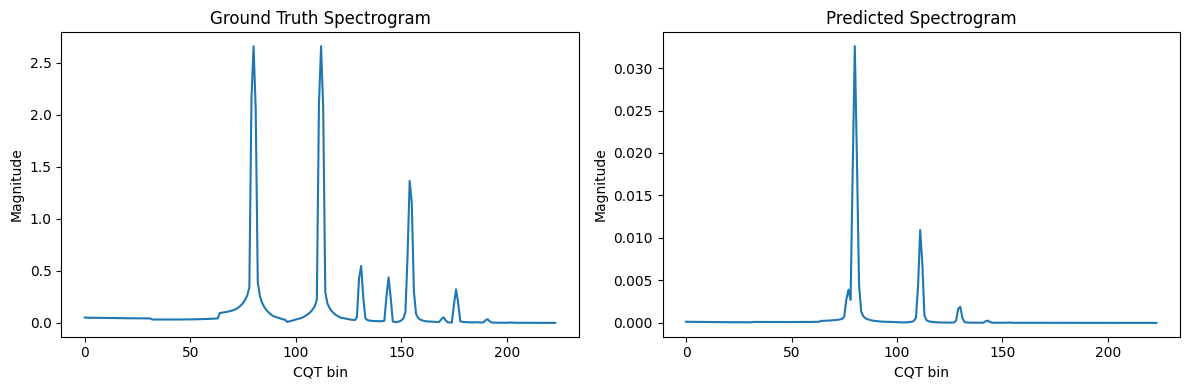

GT f0: 185.0Hz, used f0: 184.9972113558172Hz
GT ratios:    [1.5, 3.0, 2.0, 1.0]
Pred ratios:  [1.0095622539520264, 1.0181083679199219, 0.9646360874176025, 0.9997765421867371]
GT levels:    [0.10727474093437195, 0.7600628733634949, 0.9584387540817261, 0.724944531917572]
Pred levels:  [0.0007756060804240406, 0.001137793529778719, 0.9106265306472778, 0.01650966890156269]
           Ground Truth                          Predicted             
      Freq (Hz)        Mag (dB)         Freq (Hz)        Mag (dB)
----------------------------------------------------------------------
           35.7           -34.4             185.0             0.0
           62.6           -35.6             362.0            -9.5
           74.5           -38.1             546.4           -24.7
          185.0            -0.0               ---             ---
          370.0             0.0               ---             ---
          558.3           -13.7               ---             ---
          739.9         

In [21]:
# setup
device = torch.device('cpu')
Fs = 16000
duration = 1.0
hop_size = 512
bins_per_octave = 32
n_octaves = 7

# load encoder
encoder = FMEncoder(n_bins=224).to(device)
encoder.load_state_dict(torch.load('../../data/test_run/output/encoder_epoch_8.pt',
                                   map_location = device))
encoder.eval()

cqt_transform = CQT2010v2(sr=Fs,
                          hop_length = hop_size,
                          n_bins = bins_per_octave * n_octaves,
                          bins_per_octave = bins_per_octave).to(device)

# load a target audio from the dataset
spec = torch.load('../../data/test_run/spec_00000.pt',weights_only=False)
spec = torch.tensor(spec).float().to(device)

with open('../../data/test_run/params_00000.json') as f:
    params = json.load(f)
    print(f"Test Parameters: {params}")

with torch.no_grad():
    predicted = encoder(spec.unsqueeze(0))

# render audio
f0 = params['f0']

mod_matrix = make_mod_matrix(predicted['mod_values'][0])
audio = fm_renderer(f0,
                    predicted['ratios'][0],
                    predicted['levels'][0],
                    mod_matrix,
                    predicted['carrier_weights'][0],
                    Fs, duration)

# save to wav
sf.write('output.wav', audio.detach().numpy(), Fs)
print("Saved output.wav")
print("Predicted ratios:", predicted['ratios'])
print("Predicted levels:", predicted['levels'])
print("Predicted mod_values:", predicted['mod_values'])

# load ground truth parameters
with open('../../data/test_run/params_00000.json', 'r') as f:
    gt_params = json.load(f)

# render ground truth audio
gt_mod_matrix = make_mod_matrix(torch.tensor(gt_params['mod_values']))
gt_audio = fm_renderer(
    gt_params['f0'],
    torch.tensor(gt_params['ratios']),
    torch.tensor(gt_params['levels']),
    gt_mod_matrix,
    torch.tensor(gt_params['carrier_weights']),
    Fs, duration
)

# save both
sf.write('output_predicted.wav', audio.detach().numpy(), Fs)
sf.write('output_groundtruth.wav', gt_audio.detach().numpy(), Fs)

# compute spectrogram of both
pred_spec = compute_spectrogram_cqt(audio.detach(), cqt_transform)
gt_spec = compute_spectrogram_cqt(gt_audio.detach(), cqt_transform)

# plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(gt_spec.numpy())
plt.title('Ground Truth Spectrogram')
plt.xlabel('CQT bin')
plt.ylabel('Magnitude')

plt.subplot(1, 2, 2)
plt.plot(pred_spec.detach().numpy())
plt.title('Predicted Spectrogram')
plt.xlabel('CQT bin')
plt.ylabel('Magnitude')

plt.tight_layout()
plt.show()

# print parameter comparison
print(f"GT f0: {gt_params['f0']:.1f}Hz, used f0: {f0}Hz")
print(f"GT ratios:    {gt_params['ratios']}")
print(f"Pred ratios:  {predicted['ratios'][0].tolist()}")
print(f"GT levels:    {gt_params['levels']}")
print(f"Pred levels:  {predicted['levels'][0].tolist()}")

gt_peaks, gt_freqs, gt_mags = get_peaks(gt_spec, cqt_transform)
pred_peaks, pred_freqs, pred_mags = get_peaks(pred_spec, cqt_transform)

print(f"{'Ground Truth':^35} {'Predicted':^35}")
print(f"{'Freq (Hz)':>15} {'Mag (dB)':>15}   {'Freq (Hz)':>15} {'Mag (dB)':>15}")
print("-" * 70)

max_peaks = max(len(gt_peaks), len(pred_peaks))
for i in range(max_peaks):
    gt_str = f"{gt_freqs[i]:>15.1f} {20*np.log10(gt_mags[i]/gt_mags.max()):>15.1f}" if i < len(gt_peaks) else f"{'---':>15} {'---':>15}"
    pred_str = f"{pred_freqs[i]:>15.1f} {20*np.log10(pred_mags[i]/pred_mags.max()):>15.1f}" if i < len(pred_peaks) else f"{'---':>15} {'---':>15}"
    print(f"{gt_str}   {pred_str}")
                          